In [2]:
# Get ELENA
!git clone https://github.com/michelelucente/ELENA.git
%cd ELENA

# Install Python deps for notebooks + examples
# (names follow ELENA’s README; CosmoTransitions is on PyPI)
%pip install -q numpy scipy matplotlib cosmoTransitions NatPy la-forge


Cloning into 'ELENA'...
remote: Enumerating objects: 624, done.
remote: Counting objects: 100% (231/231), done.
remote: Compressing objects: 100% (137/137), done.
remote: Total 624 (delta 168), reused 142 (delta 89), pack-reused 393 (from 1)
Receiving objects: 100% (624/624), 30.17 MiB | 20.63 MiB/s, done.
Resolving deltas: 100% (426/426), done.
/content/ELENA/ELENA


In [3]:
import sys
import os
from pathlib import Path
import numpy as np
import time

# Get the directory of the current script
script_dir = Path(os.getcwd()).resolve()

# Add the src directory to the Python path
sys.path.append(str(Path(script_dir / '../src').resolve()))

figure_dir = '../data/processed/plots/manual/'
if not os.path.exists(figure_dir):
    os.makedirs(figure_dir)

In [3]:
def g_roll(lambda_):
    return ( ((16 * np.pi**2 * lambda_)/3) * (1 - lambda_ * (5 + 2*np.log(2) )/(8 * np.pi**2) ) )**(1/4)

In [4]:
# Add ELENA/src to the Python path for imports (as suggested by the repo)
import sys, os
sys.path.append(os.path.abspath('src'))

In [5]:
content = """V[phi_, T_] := (msq*ϕ^2)/2 + (λ*ϕ^4)/4 - (g1^2*Yϕ^2*ϕ^2)^(3/2)/(6*Pi) + (g1^2*Yϕ^2*Sqrt[g1^2*Yϕ^2*ϕ^2]*Sqrt[msq + λ*ϕ^2])/(16*Pi^2) + (3*λ*(msq + λ*ϕ^2))/(64*Pi^2) - (msq + λ*ϕ^2)^(3/2)/(12*Pi) + (g1^2*Yϕ^2*Sqrt[g1^2*Yϕ^2*ϕ^2]*Sqrt[msq + 3*λ*ϕ^2])/(16*Pi^2) + (λ*Sqrt[msq + λ*ϕ^2]*Sqrt[msq + 3*λ*ϕ^2])/(32*Pi^2) + (3*λ*(msq + 3*λ*ϕ^2))/(64*Pi^2) - (msq + 3*λ*ϕ^2)^(3/2)/(12*Pi) - (3*λ^2*ϕ^2*(1/2 + Log[μ3US/(3*Sqrt[msq + 3*λ*ϕ^2])]))/(16*Pi^2) + ((g1^4*Yϕ^4*ϕ^4)/(8*Pi^2) - (g1^2*Yϕ^2*ϕ^2*(-msq + 2*g1^2*Yϕ^2*ϕ^2 - 3*λ*ϕ^2))/(16*Pi^2) + (g1^2*Yϕ^2*ϕ^2*Sqrt[g1^2*Yϕ^2*ϕ^2]*Sqrt[msq + 3*λ*ϕ^2])/(8*Pi^2) - ((msq + 3*λ*ϕ^2)^2*(1/2 + Log[μ3US/Sqrt[msq + 3*λ*ϕ^2]]))/(16*Pi^2) + ((-msq + g1^2*Yϕ^2*ϕ^2 - 3*λ*ϕ^2)^2*(1/2 + Log[μ3US/(Sqrt[g1^2*Yϕ^2*ϕ^2] + Sqrt[msq + 3*λ*ϕ^2])]))/(8*Pi^2) - ((7*g1^4*Yϕ^4*ϕ^4 + (-msq + g1^2*Yϕ^2*ϕ^2 - 3*λ*ϕ^2)^2 - 2*g1^2*Yϕ^2*ϕ^2*(msq + 3*λ*ϕ^2))*(1/2 + Log[μ3US/(2*Sqrt[g1^2*Yϕ^2*ϕ^2] + Sqrt[msq + 3*λ*ϕ^2])]))/(16*Pi^2))/(4*ϕ^2) + (-1/16*(Sqrt[g1^2*Yϕ^2*ϕ^2]*(g1^2*Yϕ^2*ϕ^2 - 2*λ*ϕ^2)*Sqrt[msq + λ*ϕ^2])/Pi^2 + (Sqrt[msq + 3*λ*ϕ^2]*((g1^2*Yϕ^2*ϕ^2*Sqrt[msq + λ*ϕ^2])/(4*Pi) - (Sqrt[g1^2*Yϕ^2*ϕ^2]*(g1^2*Yϕ^2*ϕ^2 + 2*λ*ϕ^2))/(4*Pi)))/(4*Pi) + (λ^2*ϕ^4*(1/2 + Log[μ3US/(Sqrt[msq + λ*ϕ^2] + Sqrt[msq + 3*λ*ϕ^2])]))/(4*Pi^2) - ((g1^4*Yϕ^4*ϕ^4 + 4*λ^2*ϕ^4 - 2*g1^2*Yϕ^2*ϕ^2*(2*msq + 4*λ*ϕ^2))*(1/2 + Log[μ3US/(Sqrt[g1^2*Yϕ^2*ϕ^2] + Sqrt[msq + λ*ϕ^2] + Sqrt[msq + 3*λ*ϕ^2])]))/(16*Pi^2))/(4*ϕ^2) + (-1/16*(Sqrt[g1^2*Yϕ^2*ϕ^2]*(g1^2*Yϕ^2*ϕ^2 + 2*λ*ϕ^2)*Sqrt[msq + 3*λ*ϕ^2])/Pi^2 + (Sqrt[msq + λ*ϕ^2]*(-1/4*(Sqrt[g1^2*Yϕ^2*ϕ^2]*(g1^2*Yϕ^2*ϕ^2 - 2*λ*ϕ^2))/Pi + (g1^2*Yϕ^2*ϕ^2*Sqrt[msq + 3*λ*ϕ^2])/(4*Pi)))/(4*Pi) + (λ^2*ϕ^4*(1/2 + Log[μ3US/(Sqrt[msq + λ*ϕ^2] + Sqrt[msq + 3*λ*ϕ^2])]))/(4*Pi^2) - ((g1^4*Yϕ^4*ϕ^4 + 4*λ^2*ϕ^4 - 2*g1^2*Yϕ^2*ϕ^2*(2*msq + 4*λ*ϕ^2))*(1/2 + Log[μ3US/(Sqrt[g1^2*Yϕ^2*ϕ^2] + Sqrt[msq + λ*ϕ^2] + Sqrt[msq + 3*λ*ϕ^2])]))/(16*Pi^2))/(4*ϕ^2) - (λ^2*ϕ^2*(1/2 + Log[μ3US/(2*Sqrt[msq + λ*ϕ^2] + Sqrt[msq + 3*λ*ϕ^2])]))/(16*Pi^2)
"""
with open("input.m", "w", encoding="utf-8") as f:
    f.write(content)

In [6]:
#!/usr/bin/env python3
"""
Convert a Mathematica scalar potential

    V[phi_, T_] := expr
or
    V[h_, s_, T_] := expr
or
    V[{h_, s_}, T_] := expr

into a Python module with

    V(X, T)
    gradV(X, T)

and, in the one-field case only,

    dV(phi, T)

Design:
- Preserve analytic structure as faithfully as possible.
- Do NOT globally replace sqrt(x) -> sqrt(abs(x)).
- Do NOT globally replace log(x)  -> log(abs(x)).
- For one-field potentials, automatically build a small-field series
  branch to regularize removable singularities near phi = 0.
- Avoid gigantic exact integers/rationals in the printed series branch.
"""

from pathlib import Path
import re
import sympy as sp
from sympy.parsing.mathematica import parse_mathematica

INPUT_FILE = "input.m"
OUTPUT_FILE = "potential_3d.py"


# ------------------------------------------------------------------
# Mathematica symbol normalization
# ------------------------------------------------------------------

MMA_SYMBOL_MAP = {
    "ϕ": "phi",
    "φ": "phi",
    r"\[CurlyPhi]": "phi",
    r"\[Phi]": "phi",
    "λ": "lam",
    r"\[Lambda]": "lam",
    r"\[Lambda]1H": "lam1H",
    "α": "alpha",
    "β": "beta",
    "γ": "gamma",
    r"\[Alpha]": "alpha",
    r"\[Beta]": "beta",
    r"\[Gamma]": "gamma",
    "μ": "mu",
    r"\[Mu]": "mu",
    "μ3US": "mu3US",
    r"\[Mu]3US": "mu3US",
    "Pi": "pi",
    "E": "E",
}


def replace_symbols(text: str) -> str:
    for old, new in sorted(MMA_SYMBOL_MAP.items(), key=lambda kv: -len(kv[0])):
        text = text.replace(old, new)
    return text


# ------------------------------------------------------------------
# Parsing utilities
# ------------------------------------------------------------------

def remove_mathematica_comments(text: str) -> str:
    return re.sub(r"\(\*.*?\*\)", "", text, flags=re.DOTALL)


def normalize_whitespace(text: str) -> str:
    return re.sub(r"\s+", " ", text).strip()


def split_top_level_commas(s: str):
    parts = []
    depth_paren = depth_brack = depth_brace = 0
    start = 0

    for i, ch in enumerate(s):
        if ch == "(":
            depth_paren += 1
        elif ch == ")":
            depth_paren -= 1
        elif ch == "[":
            depth_brack += 1
        elif ch == "]":
            depth_brack -= 1
        elif ch == "{":
            depth_brace += 1
        elif ch == "}":
            depth_brace -= 1
        elif ch == "," and depth_paren == depth_brack == depth_brace == 0:
            parts.append(s[start:i].strip())
            start = i + 1

    parts.append(s[start:].strip())
    return parts


def find_matching_bracket(text: str, start_idx: int, open_ch="[", close_ch="]"):
    depth = 0
    for i in range(start_idx, len(text)):
        ch = text[i]
        if ch == open_ch:
            depth += 1
        elif ch == close_ch:
            depth -= 1
            if depth == 0:
                return i
    raise ValueError("No matching closing bracket found.")


def parse_v_definition(src: str):
    src = remove_mathematica_comments(src)
    src = normalize_whitespace(src)

    vpos = src.find("V")
    if vpos == -1:
        raise ValueError("Could not find function name 'V' in the file.")

    i = vpos + 1
    while i < len(src) and src[i].isspace():
        i += 1

    if i >= len(src) or src[i] != "[":
        raise ValueError("Found 'V' but not followed by '['.")

    lbrack = i
    rbrack = find_matching_bracket(src, lbrack, "[", "]")
    lhs_inside = src[lbrack + 1:rbrack].strip()

    rest = src[rbrack + 1:].lstrip()
    if rest.startswith(":="):
        rhs = rest[2:].strip()
    elif rest.startswith("="):
        rhs = rest[1:].strip()
    else:
        raise ValueError("Expected ':=' or '=' after V[...].")

    args = split_top_level_commas(lhs_inside)
    if len(args) < 2:
        raise ValueError("Expected at least one field and one temperature argument.")

    T_part = args[-1].replace("_", "").strip()
    field_parts = args[:-1]

    if len(field_parts) == 1 and field_parts[0].startswith("{") and field_parts[0].endswith("}"):
        inner = field_parts[0][1:-1].strip()
        field_names = [x.replace("_", "").strip() for x in split_top_level_commas(inner)]
    else:
        field_names = [x.replace("_", "").strip() for x in field_parts]

    if not field_names:
        raise ValueError("No field names detected in V definition.")

    return field_names, T_part, rhs


# ------------------------------------------------------------------
# Mathematica -> SymPy conversion
# ------------------------------------------------------------------

def rewrite_special_constructs(expr):
    def _rw(e):
        if not isinstance(e, sp.Basic):
            return e

        if e.is_Atom:
            return e

        args = tuple(_rw(a) for a in e.args)
        name = getattr(e.func, "__name__", str(e.func))

        if name == "If" and len(args) == 3:
            cond, a, b = args
            return sp.Piecewise((a, cond), (b, True))

        if name == "Which" and len(args) >= 2 and len(args) % 2 == 0:
            pieces = []
            for k in range(0, len(args), 2):
                pieces.append((args[k + 1], args[k]))
            return sp.Piecewise(*pieces)

        if name == "Boole" and len(args) == 1:
            return sp.Piecewise((sp.Integer(1), args[0]), (sp.Integer(0), True))

        if name in ("UnitStep", "HeavisideTheta") and len(args) == 1:
            x = args[0]
            return sp.Piecewise(
                (sp.Integer(0), x < 0),
                (sp.Rational(1, 2), sp.Eq(x, 0)),
                (sp.Integer(1), True),
            )

        try:
            return e.func(*args)
        except Exception:
            return e

    return _rw(expr)


def mma_to_sympy_expr(rhs: str):
    rhs = replace_symbols(rhs)
    expr = parse_mathematica(rhs)
    expr = rewrite_special_constructs(expr)

    try:
        expr = expr.doit()
    except Exception:
        pass

    return expr


# ------------------------------------------------------------------
# Targeted symbolic cleanup
# ------------------------------------------------------------------

def rewrite_sqrt_phi2(expr: sp.Expr) -> sp.Expr:
    """
    sqrt(x0**2) -> Abs(x0)
    sqrt(a*x0**2) -> sqrt(a)*Abs(x0) when factorization is evident
    """
    x0 = sp.Symbol("x0", real=True)

    def repl(e):
        if isinstance(e, sp.Pow) and e.exp == sp.Rational(1, 2):
            base = sp.factor(e.base)

            if base == x0**2:
                return sp.Abs(x0)

            if isinstance(base, sp.Mul):
                found_x0sq = False
                others = []
                for a in base.args:
                    if a == x0**2 and not found_x0sq:
                        found_x0sq = True
                    else:
                        others.append(a)
                if found_x0sq and others:
                    return sp.sqrt(sp.Mul(*others)) * sp.Abs(x0)

        return e

    return expr.replace(
        lambda e: isinstance(e, sp.Pow) and e.exp == sp.Rational(1, 2),
        repl,
    )


def conservative_simplify(expr: sp.Expr) -> sp.Expr:
    expr = rewrite_sqrt_phi2(expr)

    try:
        expr = sp.powsimp(expr, force=False)
    except Exception:
        pass

    try:
        expr = sp.factor_terms(expr)
    except Exception:
        pass

    return expr


# ------------------------------------------------------------------
# One-field small-phi regularization
# ------------------------------------------------------------------

def build_small_field_series(expr: sp.Expr, x: sp.Symbol, order: int = 6, digits: int = 40):
    """
    Build a small-field series branch around x=0, then numerically compress
    giant exact rational coefficients.
    """
    try:
        s = sp.series(expr, x, 0, order).removeO()
    except Exception:
        return None

    try:
        s = sp.expand(s)
    except Exception:
        pass

    try:
        # Convert huge exact rationals/integers into manageable Float coefficients
        s = sp.N(s, digits)
    except Exception:
        pass

    try:
        s = sp.simplify(s)
    except Exception:
        pass

    return s


# ------------------------------------------------------------------
# SymPy -> NumPy code printer
# ------------------------------------------------------------------

def sympy_to_numpy_code(expr: sp.Expr) -> str:
    def emit(e):
        if e == sp.pi:
            return "np.pi"
        if e == sp.E:
            return "np.e"
        if e is sp.true:
            return "True"
        if e is sp.false:
            return "False"

        if isinstance(e, sp.Integer):
            # Do NOT do int(e) here, it can trigger the Python digit limit.
            return str(e)

        if isinstance(e, sp.Float):
            return repr(float(e))

        if isinstance(e, sp.Rational):
            # Avoid giant exact rationals in printed code
            if len(str(e.p)) > 100 or len(str(e.q)) > 100:
                return repr(float(sp.N(e, 30)))
            return f"({e.p}/{e.q})"

        if isinstance(e, sp.Symbol):
            return e.name

        if isinstance(e, sp.Add):
            return "(" + " + ".join(emit(a) for a in e.args) + ")"

        if isinstance(e, sp.Mul):
            coeff, rest = e.as_coeff_Mul()
            if coeff == -1:
                return f"(-{emit(rest)})"
            return "(" + " * ".join(emit(a) for a in e.args) + ")"

        if isinstance(e, sp.Pow):
            base, exp = e.args
            if exp == sp.Rational(1, 2):
                return f"np.sqrt({emit(base)})"
            return f"({emit(base)} ** {emit(exp)})"

        if isinstance(e, sp.Piecewise):
            pieces = list(e.args)
            code = "np.nan"
            for val, cond in reversed(pieces):
                if cond is True or cond == True:
                    code = emit(val)
                else:
                    code = f"np.where({emit(cond)}, {emit(val)}, {code})"
            return code

        if isinstance(e, sp.Equality):
            return f"({emit(e.lhs)} == {emit(e.rhs)})"
        if isinstance(e, sp.Unequality):
            return f"({emit(e.lhs)} != {emit(e.rhs)})"
        if isinstance(e, sp.StrictLessThan):
            return f"({emit(e.lhs)} < {emit(e.rhs)})"
        if isinstance(e, sp.StrictGreaterThan):
            return f"({emit(e.lhs)} > {emit(e.rhs)})"
        if isinstance(e, sp.LessThan):
            return f"({emit(e.lhs)} <= {emit(e.rhs)})"
        if isinstance(e, sp.GreaterThan):
            return f"({emit(e.lhs)} >= {emit(e.rhs)})"

        if isinstance(e, sp.And):
            return "(" + " & ".join(emit(a) for a in e.args) + ")"
        if isinstance(e, sp.Or):
            return "(" + " | ".join(emit(a) for a in e.args) + ")"
        if isinstance(e, sp.Not):
            return f"(~{emit(e.args[0])})"

        fname = getattr(getattr(e, "func", None), "__name__", "")

        if fname == "Abs":
            return f"np.abs({emit(e.args[0])})"
        if fname == "log":
            return f"np.log({emit(e.args[0])})"
        if fname == "exp":
            return f"np.exp({emit(e.args[0])})"
        if fname == "sin":
            return f"np.sin({emit(e.args[0])})"
        if fname == "cos":
            return f"np.cos({emit(e.args[0])})"
        if fname == "tan":
            return f"np.tan({emit(e.args[0])})"
        if fname == "asin":
            return f"np.arcsin({emit(e.args[0])})"
        if fname == "acos":
            return f"np.arccos({emit(e.args[0])})"
        if fname == "atan":
            return f"np.arctan({emit(e.args[0])})"
        if fname == "sinh":
            return f"np.sinh({emit(e.args[0])})"
        if fname == "cosh":
            return f"np.cosh({emit(e.args[0])})"
        if fname == "tanh":
            return f"np.tanh({emit(e.args[0])})"
        if fname == "re":
            return f"np.real({emit(e.args[0])})"
        if fname == "im":
            return f"np.imag({emit(e.args[0])})"
        if fname == "Max":
            return "np.maximum.reduce([" + ", ".join(emit(a) for a in e.args) + "])"
        if fname == "Min":
            return "np.minimum.reduce([" + ", ".join(emit(a) for a in e.args) + "])"

        raise TypeError(f"Unsupported SymPy object: {type(e)} : {e}")

    return emit(expr)


# ------------------------------------------------------------------
# Main generator
# ------------------------------------------------------------------

def main():
    src = Path(INPUT_FILE).read_text(encoding="utf-8")

    field_names_raw, T_name_raw, rhs_raw = parse_v_definition(src)
    n_fields = len(field_names_raw)

    print("Detected fields:", field_names_raw)
    print("Detected T:", T_name_raw)

    X_syms = sp.symbols(" ".join(f"x{i}" for i in range(n_fields)), real=True)
    if n_fields == 1:
        X_syms = (X_syms,)
    T = sp.Symbol("T", real=True)

    expr = mma_to_sympy_expr(rhs_raw)

    subs_map = {sp.Symbol(T_name_raw): T}
    for i, nm in enumerate(field_names_raw):
        subs_map[sp.Symbol(nm)] = X_syms[i]
    expr = expr.xreplace(subs_map)

    expr = conservative_simplify(expr)

    free_syms = sorted(expr.free_symbols, key=lambda s: s.name)
    reserved_names = {T.name} | {x.name for x in X_syms}
    param_syms = [s for s in free_syms if s.name not in reserved_names]
    param_names = [s.name for s in param_syms]
    param_names_str = ", ".join(param_names) if param_names else "(none)"

    V_numpy = sympy_to_numpy_code(expr)

    if n_fields == 1:
        x0 = X_syms[0]
        series_expr = build_small_field_series(expr, x0, order=8, digits=40)
        if series_expr is not None:
            V_series_numpy = sympy_to_numpy_code(series_expr)
            small_field_block = f"""
    eps_phi = 1e-8
    out_raw = {V_numpy}
    out_series = {V_series_numpy}
    out = np.where(np.abs(x0) < eps_phi, out_series, out_raw)
"""
        else:
            small_field_block = f"""
    out = {V_numpy}
"""
    else:
        small_field_block = f"""
    out = {V_numpy}
"""

    if n_fields == 1:
        field_unpack = "    x0 = X"
    else:
        field_unpack = "\n".join([f"    x{i} = X[..., {i}]" for i in range(n_fields)])

    if param_names:
        param_extract = "\n".join([f"    {p} = params['{p}']" for p in param_names])
    else:
        param_extract = "    # no extra parameters"

    # Define original_signature here, unconditionally
    if len(field_names_raw) == 1:
        original_signature = f"V[{field_names_raw[0]}_, {T_name_raw}_]"
    else:
        original_signature = f"V[{', '.join(f + '_' for f in field_names_raw)}, {T_name_raw}_]"

    # Modify the V function signature to accept params directly
    v_function_signature = "def V(X, T, params):"

    # Modify gradV and dV function to pass params to V
    grad_body = f"""def gradV(X, T, h_rel=1e-3, h_abs=1e-5):
    T = float(T)
    X = _prepare_X(X).astype(float)
    _params_for_V = get_params(T)

    g = np.zeros_like(X, dtype=float)
    for i in range(X.shape[-1]):
        xi = X[..., i]
        hi = h_rel * np.maximum(np.abs(xi), 1.0) + h_abs

        dX = np.zeros_like(X, dtype=float)
        dX[..., i] = hi

        g[..., i] = (V(X + dX, T, _params_for_V) - V(X - dX, T, _params_for_V)) / (2.0 * hi)

    return g
"""

    one_field_alias = f"""
def dV(phi, T, h_rel=1e-3, h_abs=1e-5):
    phi = np.asarray(phi, dtype=float)
    _params_for_V = get_params(T)
    h = h_rel * np.maximum(np.abs(phi), 1.0) + h_abs
    return (V(phi + h, T, _params_for_V) - V(phi - h, T, _params_for_V)) / (2.0 * h)
"""

    # prepare_x_code needs to be defined based on n_fields, moved here
    if n_fields == 1:
        prepare_x_code = """def _prepare_X(X):
    return np.asarray(X, dtype=float)
"""
    else:
        prepare_x_code = f"""def _prepare_X(X):
    X = np.asarray(X, dtype=float)
    if X.shape[-1] != {n_fields}:
        raise ValueError(f"Expected X.shape[-1] == {n_fields}, got {{X.shape}}")
    return X
"""



    out = f'''"""
Auto-generated from Mathematica potential.

Original definition:
    {original_signature} := {rhs_raw}

Detected fields:
    {", ".join(field_names_raw)}

Detected free parameters (besides fields, T):
    {param_names_str}

You MUST implement get_params(T).
"""

import numpy as np


def get_params(T):
    raise NotImplementedError(
        "Implement get_params(T) so that it returns a dict with keys: {param_names_str}"
    )


{prepare_x_code}

{v_function_signature}
    T = float(T)
    X = _prepare_X(X)
{field_unpack}

    # params is now passed directly, no need to call get_params(T) here
{param_extract}
{small_field_block}
    return np.asarray(out)


{grad_body}{one_field_alias}
'''

    Path(OUTPUT_FILE).write_text(out, encoding="utf-8")
    print(f"Wrote {OUTPUT_FILE}")
    print(f"Fields: {field_names_raw}")
    print(f"Parameters: {param_names_str}")


if __name__ == "__main__":
    main()

Detected fields: ['phi']
Detected T: T
Wrote potential_3d.py
Fields: ['phi']
Parameters: Yphi, g1, lam, msq, mu3US


In [7]:

%%writefile model_3d.py
import numpy as np
from scipy.integrate import solve_ivp

# Your auto-generated 2-loop 3D potential module
import potential_3d as pot3d


class AbelianHiggsDR3D:
    """
    Consistent 3D DR/Usoft EFT model for the Abelian Higgs system.

    Schemes:
        - "3D-1L-LO"
        - "3D-1L-NLO"
        - "3D-2L-NLO"
        - "3D-2L-MIXED"

    Conventions:
        4D running uses the DRalgo / Mathematica sign convention visible in your outputs:
            V_4D(tree) = + msq * phi^2 / 2 + lam * phi^4 / 4
        so msq here is the same object that appears in your PrintBetaFunctions4D[] result.

    For 2-loop schemes, this wrapper uses your generated potential_3d.py.
    For 1-loop schemes, it uses the analytic 1-loop 3D EFT potential.

    The 4D-equivalent mapped potential is
        V4_equiv(phi4, T) = T * V3(phi4 / sqrt(T), T)
    which is the standard comparison map used in the paper.
    """

    VALID_SCHEMES = {
        "3D-1L-LO",
        "3D-1L-NLO",
        "3D-2L-NLO",
        "3D-2L-MIXED",
    }

    def __init__(
        self,
        g1_0=0.6,
        lam_0=0.0,
        msq_0=0.0,
        mu0=1.0,
        Yphi=1.0,
        scheme="3D-2L-NLO",
        use_running=True,
    ):
        if scheme not in self.VALID_SCHEMES:
            raise ValueError(f"Unknown scheme '{scheme}'. Valid: {sorted(self.VALID_SCHEMES)}")

        self.g1_0 = float(g1_0)
        self.g2_0 = self.g1_0 ** 2
        self.lam_0 = float(lam_0)
        self.msq_0 = float(msq_0)
        self.mu0 = float(mu0)
        self.Yphi = float(Yphi)
        self.scheme = scheme
        self.use_running = bool(use_running)

        self._rge_cache = {}

        # constants
        self.gammaE = 0.5772156649015328606
        self.logA = 0.2487544770337842771  # log Glaisher-Kinkelin
        self.pi = np.pi

    # ============================================================
    # 4D RG running in the same convention as your DR outputs
    # ============================================================
    def _rge_rhs(self, t, y):
        """
        t = ln(mu / mu0)
        y = [g2, lam, msq]
        Using the beta functions visible in your Mathematica screenshot.
        """
        g2, lam, msq = y
        Y2 = self.Yphi ** 2
        Y4 = self.Yphi ** 4

        beta_g2 = (g2 ** 2) * Y2 / (24.0 * self.pi ** 2)
        beta_lam = (3.0 * g2 ** 2 * Y4 - 6.0 * g2 * lam * Y2 + 10.0 * lam ** 2) / (8.0 * self.pi ** 2)
        beta_msq = msq * (3.0 * g2 * Y2 - 4.0 * lam) / (8.0 * self.pi ** 2)

        return [beta_g2, beta_lam, beta_msq]

    def run_4d(self, mu):
        mu = max(float(mu), 1e-12)

        if not self.use_running:
            return self.g2_0, self.lam_0, self.msq_0

        key = round(mu, 12)
        if key in self._rge_cache:
            return self._rge_cache[key]

        if abs(mu - self.mu0) / max(self.mu0, 1e-12) < 1e-14:
            out = (self.g2_0, self.lam_0, self.msq_0)
            self._rge_cache[key] = out
            return out

        t1 = np.log(mu / self.mu0)
        sol = solve_ivp(
            self._rge_rhs,
            (0.0, t1),
            [self.g2_0, self.lam_0, self.msq_0],
            method="RK45",
            rtol=1e-9,
            atol=1e-11,
            dense_output=False,
            max_step=max(abs(t1) / 200.0, 1e-3),
        )
        if not sol.success:
            raise RuntimeError(f"4D RGE evolution failed: {sol.message}")

        out = tuple(float(v) for v in sol.y[:, -1])
        self._rge_cache[key] = out
        return out

    # ============================================================
    # Scale choices from Table I
    # ============================================================
    def mu_match(self, T):
        return max(2.0 * self.pi * float(T), 1e-12)

    def mu3(self, T):
        """
        Soft/3D scale mu3 = g T, using the 4D running gauge coupling
        evaluated at mu_match.
        """
        T = float(T)
        mu_m = self.mu_match(T)
        g2, _, _ = self.run_4d(mu_m)
        g = np.sqrt(max(g2, 0.0))
        return max(g * T, 1e-12)

    # ============================================================
    # DR constants
    # ============================================================
    def Lb(self, T):
        """
        Lb = 2 gamma_E - 2 log(4 pi) + log(mu_match^2 / T^2)
        """
        T = float(T)
        mu_m = self.mu_match(T)
        return 2.0 * self.gammaE - 2.0 * np.log(4.0 * self.pi) + np.log(mu_m ** 2 / (T ** 2))

    def c_plus(self, T):
        return 0.5 * (self.gammaE - self.Lb(T) - 12.0 * self.logA)

    # ============================================================
    # Matched couplings and masses
    # ============================================================
    def params_3d(self, T):
        """
        Return a complete dictionary of LO and NLO matched parameters.
        """
        T = float(T)
        if T <= 0.0:
            raise ValueError("3D EFT parameters are only meaningful for T > 0.")

        mu_m = self.mu_match(T)
        mu_3 = self.mu3(T)

        g2, lam, msq = self.run_4d(mu_m)
        Y2 = self.Yphi ** 2
        Y4 = self.Yphi ** 4
        Lb = self.Lb(T)
        cplus = self.c_plus(T)

        # ----------------------------
        # LO couplings
        # ----------------------------
        g3sq_lo = g2 * T
        lam3_lo = lam * T

        # temporal scalar coupling at LO
        lambdaVL_lo = 2.0 * g2 * T * Y2
        lambdaVLL_lo = 0.0

        # ----------------------------
        # NLO couplings from your DR output / appendix formulas
        # ----------------------------
        g3sq_nlo = g2 * T - (g2 ** 2) * Lb * T * Y2 / (48.0 * self.pi ** 2)

        lam3_nlo = T * (
            (g2 ** 2) * (2.0 - 3.0 * Lb) * Y4
            + 6.0 * g2 * Lb * Y2 * lam
            + 2.0 * lam * (8.0 * self.pi ** 2 - 5.0 * Lb * lam)
        ) / (16.0 * self.pi ** 2)

        lambdaVLL_nlo = (g2 ** 2) * T * Y4 / (self.pi ** 2)

        lambdaVL_nlo = (
            g2 * T * Y2
            * (48.0 * self.pi ** 2 - g2 * (-4.0 + Lb) * Y2 + 24.0 * lam)
            / (24.0 * self.pi ** 2)
        )

        # ----------------------------
        # LO scalar mass and Debye mass
        # ----------------------------
        msq3d_lo = msq + (T ** 2) * (3.0 * g2 * Y2 + 4.0 * lam) / 12.0

        mD2_lo = g2 * T ** 2 * Y2 / 3.0

        # ----------------------------
        # NLO Debye mass from your screenshot
        # ----------------------------
        mD2_nlo = (
            mD2_lo
            + g2 * Y2 * (
                36.0 * msq
                + 7.0 * g2 * T ** 2 * Y2
                - 2.0 * self.gammaE * g2 * T ** 2 * Y2
                + 12.0 * T ** 2 * lam
                + 2.0 * g2 * T ** 2 * Y2 * np.log(4.0 * self.pi * T)
                - 2.0 * g2 * T ** 2 * Y2 * np.log(mu_m)
            ) / (144.0 * self.pi ** 2)
        )

        # ----------------------------
        # NLO scalar mass
        #
        # This matches the structure shown in your DRalgo printout:
        # tree/NLO mass + log(mu3/mu_match) piece.
        # ----------------------------
        # First define the couplings entering the log term
        # for the NLO scheme
        logterm_nlo = (
            8.0 * (g3sq_nlo ** 2) * Y4
            - 16.0 * g3sq_nlo * Y2 * lam3_nlo
            + 16.0 * (lam3_nlo ** 2)
            + lambdaVL_nlo ** 2
        )

        msq3d_nlo = (
            12.0 * g2 * Y2 * (
                Lb * (9.0 * msq - 6.0 * T ** 2 * lam)
                + 2.0 * T ** 2 * lam * (1.0 + 6.0 * self.gammaE - 72.0 * self.logA)
            )
            + 24.0 * lam * (
                Lb * (-6.0 * msq + T ** 2 * lam)
                - 6.0 * T ** 2 * lam * (self.gammaE - 12.0 * self.logA)
            )
            + (g2 ** 2) * T ** 2 * Y4 * (
                -8.0 - 108.0 * self.gammaE + 69.0 * Lb + 1296.0 * self.logA
            )
            + 18.0 * np.log(mu_3 / mu_m) * logterm_nlo
        ) / (576.0 * self.pi ** 2)

        # add the LO part
        msq3d_nlo = msq3d_lo + msq3d_nlo

        # ----------------------------
        # Mixed mass:
        # use NLO mass formula but LO couplings inside the log term,
        # matching the "tree level at NLO, higher orders at LO" spirit.
        # ----------------------------
        logterm_mixed = (
            8.0 * (g3sq_lo ** 2) * Y4
            - 16.0 * g3sq_lo * Y2 * lam3_lo
            + 16.0 * (lam3_lo ** 2)
            + lambdaVL_lo ** 2
        )

        msq3d_mixed = (
            12.0 * g2 * Y2 * (
                Lb * (9.0 * msq - 6.0 * T ** 2 * lam)
                + 2.0 * T ** 2 * lam * (1.0 + 6.0 * self.gammaE - 72.0 * self.logA)
            )
            + 24.0 * lam * (
                Lb * (-6.0 * msq + T ** 2 * lam)
                - 6.0 * T ** 2 * lam * (self.gammaE - 12.0 * self.logA)
            )
            + (g2 ** 2) * T ** 2 * Y4 * (
                -8.0 - 108.0 * self.gammaE + 69.0 * Lb + 1296.0 * self.logA
            )
            + 18.0 * np.log(mu_3 / mu_m) * logterm_mixed
        ) / (576.0 * self.pi ** 2)

        msq3d_mixed = msq3d_lo + msq3d_mixed

        # ----------------------------
        # Ultrasoft scalar masses
        # LO:  msqUS = msq3d - sqrt(mD2) * lambdaVL / (8 pi)
        # NLO: add the explicit ultrasoft correction from your screenshot
        # ----------------------------
        def us_lo(msq3d, mD2, lambdaVL):
            return msq3d - np.sqrt(max(mD2, 0.0)) * lambdaVL / (8.0 * self.pi)

        def us_nlo(msq3d, mD2, lambdaVL, lambdaVLL):
            md = np.sqrt(max(mD2, 1e-30))
            return (
                us_lo(msq3d, mD2, lambdaVL)
                + lambdaVL * (
                    -2.0 * lambdaVL
                    - 4.0 * np.log(mu_3 / (2.0 * md)) * lambdaVL
                    + lambdaVLL
                ) / (128.0 * self.pi ** 2)
            )

        msqUS_lo = us_lo(msq3d_lo, mD2_lo, lambdaVL_lo)
        msqUS_nlo = us_nlo(msq3d_nlo, mD2_nlo, lambdaVL_nlo, lambdaVLL_nlo)
        msqUS_mixed = us_nlo(msq3d_mixed, mD2_nlo, lambdaVL_lo, lambdaVLL_lo)

        return {
            "mu_match": mu_m,
            "mu3": mu_3,
            "g2_4d": g2,
            "g1_4d": np.sqrt(max(g2, 0.0)),
            "lam_4d": lam,
            "msq_4d": msq,

            "g3sq_lo": g3sq_lo,
            "g3sq_nlo": g3sq_nlo,

            "lam3_lo": lam3_lo,
            "lam3_nlo": lam3_nlo,

            "lambdaVL_lo": lambdaVL_lo,
            "lambdaVL_nlo": lambdaVL_nlo,
            "lambdaVLL_lo": lambdaVLL_lo,
            "lambdaVLL_nlo": lambdaVLL_nlo,

            "mD2_lo": mD2_lo,
            "mD2_nlo": mD2_nlo,

            "msq3d_lo": msq3d_lo,
            "msq3d_nlo": msq3d_nlo,
            "msq3d_mixed": msq3d_mixed,

            "msqUS_lo": msqUS_lo,
            "msqUS_nlo": msqUS_nlo,
            "msqUS_mixed": msqUS_mixed,
        }

    # ============================================================
    # Scheme-dependent parameter pack for the potential
    # ============================================================
    def get_params(self, T):
        p = self.params_3d(T)

        if self.scheme == "3D-1L-LO":
            g3sq = p["g3sq_lo"]
            lam3 = p["lam3_lo"]
            msqUS = p["msqUS_lo"]

        elif self.scheme == "3D-1L-NLO":
            g3sq = p["g3sq_nlo"]
            lam3 = p["lam3_nlo"]
            msqUS = p["msqUS_nlo"]

        elif self.scheme == "3D-2L-NLO":
            g3sq = p["g3sq_nlo"]
            lam3 = p["lam3_nlo"]
            msqUS = p["msqUS_nlo"]

        elif self.scheme == "3D-2L-MIXED":
            g3sq = p["g3sq_lo"]
            lam3 = p["lam3_lo"]
            msqUS = p["msqUS_mixed"]

        else:
            raise RuntimeError("Unreachable scheme branch.")

        return {
            "Yphi": self.Yphi,
            "g1": np.sqrt(max(g3sq, 0.0)),  # dimensionful 3D gauge coupling
            "lam": lam3,                    # dimensionful 3D quartic
            "msq": msqUS,                   # ultrasoft scalar mass
            "mu3US": p["mu3"],              # ultrasoft renormalisation scale
        }

    # ============================================================
    # Analytic 1-loop 3D EFT potential
    # ============================================================
    @staticmethod
    def _pow32_real(x):
        """
        Real-valued implementation of x^(3/2) for EFT scans.
        """
        x = np.asarray(x, dtype=float)
        return np.power(np.maximum(x, 0.0), 1.5)

    def V3_1loop(self, phi, T):
        pars = self.get_params(T)
        phi = np.asarray(phi, dtype=float)

        Yphi = pars["Yphi"]
        g3 = pars["g1"]
        lam3 = pars["lam"]
        msq = pars["msq"]

        mA2 = (g3 ** 2) * (Yphi ** 2) * (phi ** 2)
        mG2 = msq + lam3 * phi ** 2
        mH2 = msq + 3.0 * lam3 * phi ** 2

        Vtree = 0.5 * msq * phi ** 2 + 0.25 * lam3 * phi ** 4
        V1 = (
            - self._pow32_real(mA2) / (6.0 * self.pi)
            - self._pow32_real(mG2) / (12.0 * self.pi)
            - self._pow32_real(mH2) / (12.0 * self.pi)
        )

        return np.asarray(Vtree + V1)

    # ============================================================
    # Full 2-loop 3D EFT potential via the generated module
    # ============================================================
    def V3_2loop(self, phi, T):
        pars = self.get_params(T)
        out = pot3d.V(phi, T, pars)
        return np.asarray(out)

    # ============================================================
    # Main 3D potential dispatch
    # ============================================================
    def V3(self, phi, T):
        if self.scheme in {"3D-1L-LO", "3D-1L-NLO"}:
            return self.V3_1loop(phi, T)
        return self.V3_2loop(phi, T)

    # ============================================================
    # 4D-equivalent mapped potential for comparison / ELENA-style use
    # phi4 is the 4D-normalized field
    # ============================================================
    def V4_equiv(self, phi4, T):
        T = float(T)
        if T <= 0.0:
            raise ValueError("V4_equiv is only meaningful for T > 0.")

        phi4 = np.asarray(phi4, dtype=float)
        phi3 = phi4 / np.sqrt(T)
        return T * self.V3(phi3, T)

    def dV4_equiv(self, phi4, T, h_rel=1e-4, h_abs=1e-6):
        phi4 = np.asarray(phi4, dtype=float)
        h = h_rel * np.maximum(np.abs(phi4), 1.0) + h_abs
        return (self.V4_equiv(phi4 + h, T) - self.V4_equiv(phi4 - h, T)) / (2.0 * h)

    # optional aliases
    def V(self, phi4, T):
        return self.V4_equiv(phi4, T)

    def dV(self, phi4, T):
        return self.dV4_equiv(phi4, T)

Writing model_3d.py


In [87]:
import numpy as np
import sys, importlib

# Reload modules if already imported
if 'potential_3d' in sys.modules:
    importlib.reload(sys.modules['potential_3d'])
if 'model_3d' in sys.modules:
    importlib.reload(sys.modules['model_3d'])

from model_3d import AbelianHiggsDR3D

# ============================================================
# Paper-style benchmark
# g(mu0)=0.6, mu0=1 GeV, lambda(mu0)=0, msq(mu0)=0
# ============================================================
description = "3D DR benchmark (g=0.6)"
g0 = 0.60
lam0 = 0.0
msq0 = 0.0
mu0 = 1.0   # GeV
Yphi = 1.0

# Choose DR scheme:
# "3D-1L-LO"
# "3D-1L-NLO"
# "3D-2L-NLO"
# "3D-2L-MIXED"
scheme = "3D-2L-MIXED"

# Build the 3D model
dp = AbelianHiggsDR3D(
    g1_0=g0,
    lam_0=lam0,
    msq_0=msq0,
    mu0=mu0,
    Yphi=Yphi,
    scheme=scheme,
    use_running=True,
)

phi_test = 10.0
T_test = 0.2  # GeV

# ============================================================
# Wrappers
# V3 uses native 3D field normalization
# V4_equiv is the mapped 4D-equivalent potential:
#     V4_equiv(phi4,T) = T * V3(phi4/sqrt(T), T)
# ============================================================
V3  = lambda phi, T: np.asarray(dp.V3(np.asarray(phi, dtype=float), T))
V4  = lambda phi, T: np.asarray(dp.V4_equiv(np.asarray(phi, dtype=float), T))
dV4 = lambda phi, T: np.asarray(dp.dV4_equiv(np.asarray(phi, dtype=float), T))

# Matched parameters at T_test
pars = dp.get_params(T_test)
all_pars = dp.params_3d(T_test)

print(description)
print("scheme =", scheme)
print()


print("V3(10,0.2) =", V3(phi_test, T_test))

print("Mapped 4D-equivalent potential:")
print("V4_equiv(10,0.2) =", V4(phi_test, T_test))
print("dV4_equiv/dphi(10,0.2) =", dV4(phi_test, T_test))
print()

print("Reference-scale inputs:")
print("  mu0 =", dp.mu0)
print("  g(mu0) =", dp.g1_0)
print("  lambda(mu0) =", dp.lam_0)
print("  msq(mu0) =", dp.msq_0)
print()

print("Scale choices at T_test:")
print("  mu_match =", all_pars["mu_match"])
print("  mu3 =", all_pars["mu3"])
print()

print("Running 4D parameters at mu_match:")
print("  g^2(mu_match) =", all_pars["g2_4d"])
print("  g(mu_match) =", all_pars["g1_4d"])
print("  lambda(mu_match) =", all_pars["lam_4d"])
print("  msq(mu_match) =", all_pars["msq_4d"])
print()

print("Matched 3D / US parameters actually used by the potential:")
print("  Yphi =", pars["Yphi"])
print("  g1 (3D) =", pars["g1"])
print("  lam (3D) =", pars["lam"])
print("  msq (US) =", pars["msq"])
print("  mu3US =", pars["mu3US"])
print()



3D DR benchmark (g=0.6)
scheme = 3D-2L-MIXED

V3(10,0.2) = -0.29538555776910613
Mapped 4D-equivalent potential:
V4_equiv(10,0.2) = 0.6851981249801612
dV4_equiv/dphi(10,0.2) = 0.4691559955969484

Reference-scale inputs:
  mu0 = 1.0
  g(mu0) = 0.6
  lambda(mu0) = 0.0
  msq(mu0) = 0.0

Scale choices at T_test:
  mu_match = 1.2566370614359172
  mu3 = 0.12002083657870535

Running 4D parameters at mu_match:
  g^2(mu_match) = 0.3601250303263073
  g(mu_match) = 0.6001041828935267
  lambda(mu_match) = 0.001121775868489595
  msq(mu_match) = 0.0

Matched 3D / US parameters actually used by the potential:
  Yphi = 1.0
  g1 (3D) = 0.26837474930637845
  lam (3D) = 0.00022435517369791898
  msq (US) = 0.002948270481903143
  mu3US = 0.12002083657870535



In [88]:
import numpy as np
import temperatures as temp


def find_extrema_fast(V, dV, T, Phimax=150, step=1, *, max_expand=10, Phimax_cap=2e4):

    T = float(T)
    if T < 0:
        return [], [], []

    Phimax = float(Phimax)
    step   = float(step)

    # ELENA-like: start at phi=step, not phi=0
    phi = np.arange(step, Phimax + step, step, dtype=float).reshape(-1, 1)

    def _eval_V(phi_grid):
        return np.asarray(V(phi_grid, T), dtype=float).reshape(-1)

    def _eval_dV(phi_grid):
        try:
            out = np.asarray(dV(phi_grid, T), dtype=float).reshape(-1)
            if np.all(np.isfinite(out)):
                return out
        except Exception:
            pass
        return None

    v = _eval_V(phi)

    # expand search range if the maximum is sitting at the boundary
    argmaxV = np.argmax(v)
    expand_counter = 0
    while (argmaxV + 1) != len(v):
        if np.isnan(v[argmaxV]):
            return [], [], []
        expand_counter += 1
        if expand_counter > max_expand or Phimax >= Phimax_cap:
            break
        Phimax = min(Phimax_cap, 2.0 * Phimax)
        phi = np.arange(step, Phimax + step, step, dtype=float).reshape(-1, 1)
        v = _eval_V(phi)
        argmaxV = np.argmax(v)

    if len(v) < 5 or not np.all(np.isfinite(v)):
        return [], [], []

    phi1 = phi.reshape(-1)

    # Prefer analytic/numerical wrapper derivative if supplied
    dv = _eval_dV(phi)
    if dv is None or len(dv) != len(phi1):
        dv = np.gradient(v, phi1)

    if not np.all(np.isfinite(dv)):
        return [], [], []

    signs = np.sign(dv).reshape(-1)
    signs = np.round(signs).astype(int)

    # clean zeros to avoid fake/missed sign flips
    for i in range(1, len(signs)):
        if signs[i] == 0:
            signs[i] = signs[i - 1]
    for i in range(len(signs) - 2, -1, -1):
        if signs[i] == 0:
            signs[i] = signs[i + 1]

    sign_changes = np.diff(signs)   # negative => max, positive => min
    change_indices = np.nonzero(np.abs(sign_changes) == 2)[0]

    # ELENA-like de-dup of consecutive flips
    filtered = []
    previous = -999999
    for idx in np.flip(change_indices):
        if idx != previous - 1:
            filtered.append(idx)
        previous = idx
    filtered = np.flip(np.array(filtered, dtype=int))

    loc, val, kind = [], [], []

    for idx in filtered:
        this_kind = "max" if sign_changes[idx] < 0 else "min"

        dv_pair  = dv[idx:idx + 2]
        phi_pair = phi1[idx:idx + 2]
        v_pair   = v[idx:idx + 2]

        if len(dv_pair) < 2:
            continue

        # linear interpolation of dV=0 crossing
        try:
            if this_kind == "max":
                xz = np.interp(0.0, dv_pair[::-1], phi_pair[::-1])
            else:
                xz = np.interp(0.0, dv_pair, phi_pair)
        except Exception:
            xz = 0.5 * (phi_pair[0] + phi_pair[1])

        vz = np.interp(xz, phi_pair, v_pair)

        kind.append(this_kind)
        loc.append(float(xz))
        val.append(float(vz))

    if len(kind) == 0:
        return [], [], []

    # sort by field location
    order = np.argsort(loc)
    kind = list(np.array(kind)[order])
    loc  = list(np.array(loc)[order])
    val  = list(np.array(val)[order])

    # ELENA-like truncation after the global minimum
    if len(kind) > 2:
        gmin = int(np.argmin(val))
        kind = kind[:gmin + 1]
        loc  = loc[:gmin + 1]
        val  = val[:gmin + 1]

    return kind, loc, val


# patch temperatures module
temp.find_extrema = find_extrema_fast

In [117]:
import numpy as np
import sys, importlib

# Reload if needed
if 'model_3d' in sys.modules:
    importlib.reload(sys.modules['model_3d'])

from temperatures import find_T_min, find_T_max, refine_Tmin
from model_3d import AbelianHiggsDR3D

# ============================================================
# Paper-style DR benchmark
# ============================================================
description = "3D DR benchmark (g=0.6)"
g0    = 0.6
lam0  = 0.0
msq0  = 0.0
mu0   = 1.0    # GeV
Yphi  = 1.0

scheme = "3D-2L-MIXED"
use_running = True

dp = AbelianHiggsDR3D(
    g1_0=g0,
    lam_0=lam0,
    msq_0=msq0,
    mu0=mu0,
    Yphi=Yphi,
    scheme=scheme,
    use_running=use_running,
)

# ============================================================
# Safe wrappers for ELENA temperature scans
#
# temperatures.find_T_min may probe T=0, so we must not call
# dp.V4_equiv() there because it explicitly requires T>0.
#
# For T>0: use the mapped 4D-equivalent potential
# For T<=0: fall back to a tiny positive temperature
# ============================================================
T_floor = 1e-12

def V(phi, T):
    phi = np.asarray(phi, dtype=float)
    Teff = max(float(T), T_floor)
    return np.asarray(dp.V4_equiv(phi, Teff), dtype=float)

def dV(phi, T):
    phi = np.asarray(phi, dtype=float)
    Teff = max(float(T), T_floor)
    return np.asarray(dp.dV4_equiv(phi, Teff), dtype=float)

# ============================================================
# Scan settings
# ============================================================
units = "GeV"
vev_guess = mu0

Phimax = 2.5 * vev_guess
tmax   = 3.0 * vev_guess
T_step = 1e-2

# ============================================================
# ELENA-style temperature scan
# ============================================================
T_max, vevs_max, max_min_vals, false_min_tmax = find_T_max(
    V, dV,
    precision=1e-2,
    Phimax=Phimax,
    step_phi=vev_guess * T_step,
    tmax=tmax
)

T_min, vevs_min, false_min_tmin = find_T_min(
    V, dV,
    tmax=T_max,
    precision=1e-2,
    Phimax=Phimax,
    step_phi=vev_guess * T_step,
    max_min_vals=max_min_vals
)

if T_max is not None and T_min is not None:
    maxvev = np.max(np.concatenate((vevs_max, vevs_min)))
elif T_max is not None:
    maxvev = np.max(vevs_max)
elif T_min is not None:
    maxvev = np.max(vevs_min)
else:
    maxvev = None

T_min = refine_Tmin(T_min, V, dV, maxvev, log_10_precision=6) if T_min is not None else None

# ============================================================
# Print results
# ============================================================
print(description)
print("scheme =", scheme)
print("use_running =", use_running)
print()

print(f"T_max = {T_max:.6e} {units}" if T_max is not None else "T_max = None")
print(f"T_min = {T_min:.6e} {units}" if T_min is not None else "T_min = None")
print(f"maxvev = {maxvev:.6e} {units}" if maxvev is not None else "maxvev = None")
print()

if false_min_tmax is not None:
    print("false_min_tmax =", false_min_tmax)
if false_min_tmin is not None:
    print("false_min_tmin =", false_min_tmin)
print()

if vevs_max is not None:
    print("vevs_max (sample):", vevs_max[:10])
if vevs_min is not None:
    print("vevs_min (sample):", vevs_min[:10])
if max_min_vals is not None:
    print("max_min_vals =", max_min_vals)

3D DR benchmark (g=0.6)
scheme = 3D-2L-MIXED
use_running = True

T_max = 3.081000e-01 GeV
T_min = 1.591641e-01 GeV
maxvev = 1.685197e+02 GeV

false_min_tmax = [0, 0]
false_min_tmin = [0, 0]

vevs_max (sample): [2.26821107 2.18300765 2.1528374 ]
vevs_min (sample): [168.51970666]
max_min_vals = [np.float64(1.081018023925181), np.float64(2.1528373989002128)]


In [118]:
T_max, vevs_max, max_min_vals, false_min_tmax

(np.float64(0.3081000000000175),
 array([2.26821107, 2.18300765, 2.1528374 ]),
 [np.float64(1.081018023925181), np.float64(2.1528373989002128)],
 [0, 0])

In [119]:
T_min, vevs_min, false_min_tmin

(np.float64(0.15916412403499164), array([168.51970666]), [0, 0])

In [120]:
maxvev

np.float64(168.51970665903963)

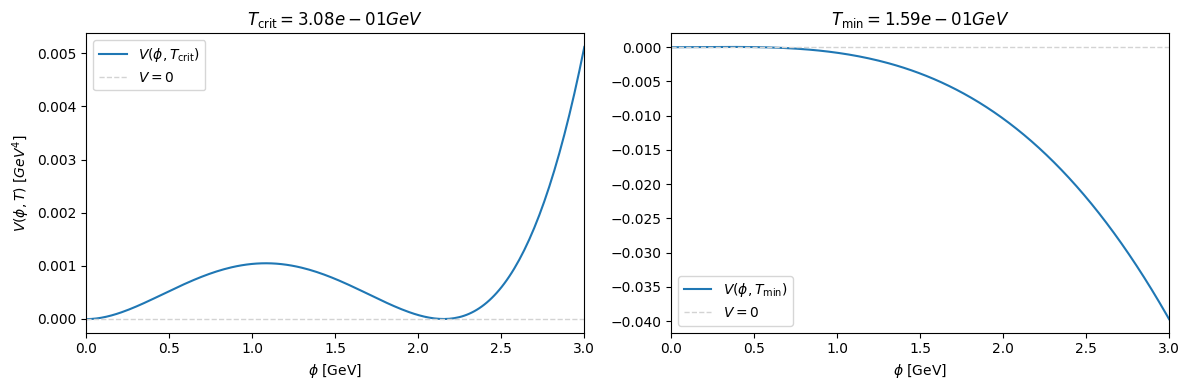

In [122]:
import matplotlib.pyplot as plt

plt.rcParams['text.usetex'] = False

# Define a plotting range (no vev anymore)
phi = np.linspace(0.0, 3.0, 200)  # adjust if needed

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# -------------------------
# Critical temperature plot
# -------------------------
if T_max is not None:
    v_max = V(phi, T_max)
    axes[0].plot(phi, v_max, label=r'$V(\phi, T_{\mathrm{crit}})$')
    axes[0].set_title(f'$T_{{\\mathrm{{crit}}}} = {T_max:.2e} {units}$')
    axes[0].set_xlim(phi[0], phi[-1])
    axes[0].set_ylabel(f"$V(\\phi, T)$ $[{units}^4]$")

# -------------------------
# Barrier disappearance plot
# -------------------------
if T_min is not None:
    v_min = V(phi, T_min)
    axes[1].plot(phi, v_min, label=r'$V(\phi, T_{\mathrm{min}})$')
    axes[1].set_title(f'$T_{{\\mathrm{{min}}}} = {T_min:.2e} {units}$')
    axes[1].set_xlim(phi[0], phi[-1])

# -------------------------
# Common formatting
# -------------------------
for ax in axes:
    ax.set_xlabel(f"$\\phi$ [{units}]")
    ax.axhline(0.0, color='lightgrey', linestyle='--', linewidth=1, label="$V=0$")
    ax.legend()

plt.tight_layout()
plt.show()

In [123]:
T_floor = 1e-12

def V(phi, T):
    Teff = max(float(T), T_floor)
    phi = np.asarray(phi, dtype=float)
    out = np.asarray(dp.V4_equiv(phi, Teff), dtype=float)
    return float(out) if out.ndim == 0 else out.reshape(-1)

def dV(phi, T):
    Teff = max(float(T), T_floor)
    phi = np.asarray(phi, dtype=float)
    out = np.asarray(dp.dV4_equiv(phi, Teff), dtype=float)
    return float(out) if out.ndim == 0 else out.reshape(-1)

In [126]:
n_points = 100
temperatures = np.linspace(T_min, T_max, n_points)
action_vec = np.vectorize(action_over_T)

start_time = time.time()
action_vec(temperatures)
end_time = time.time()
print(f"Elapsed time: {end_time - start_time:.2f} seconds")

temperatures = np.array([T for T in temperatures if T in S3overT])

Elapsed time: 5.17 seconds


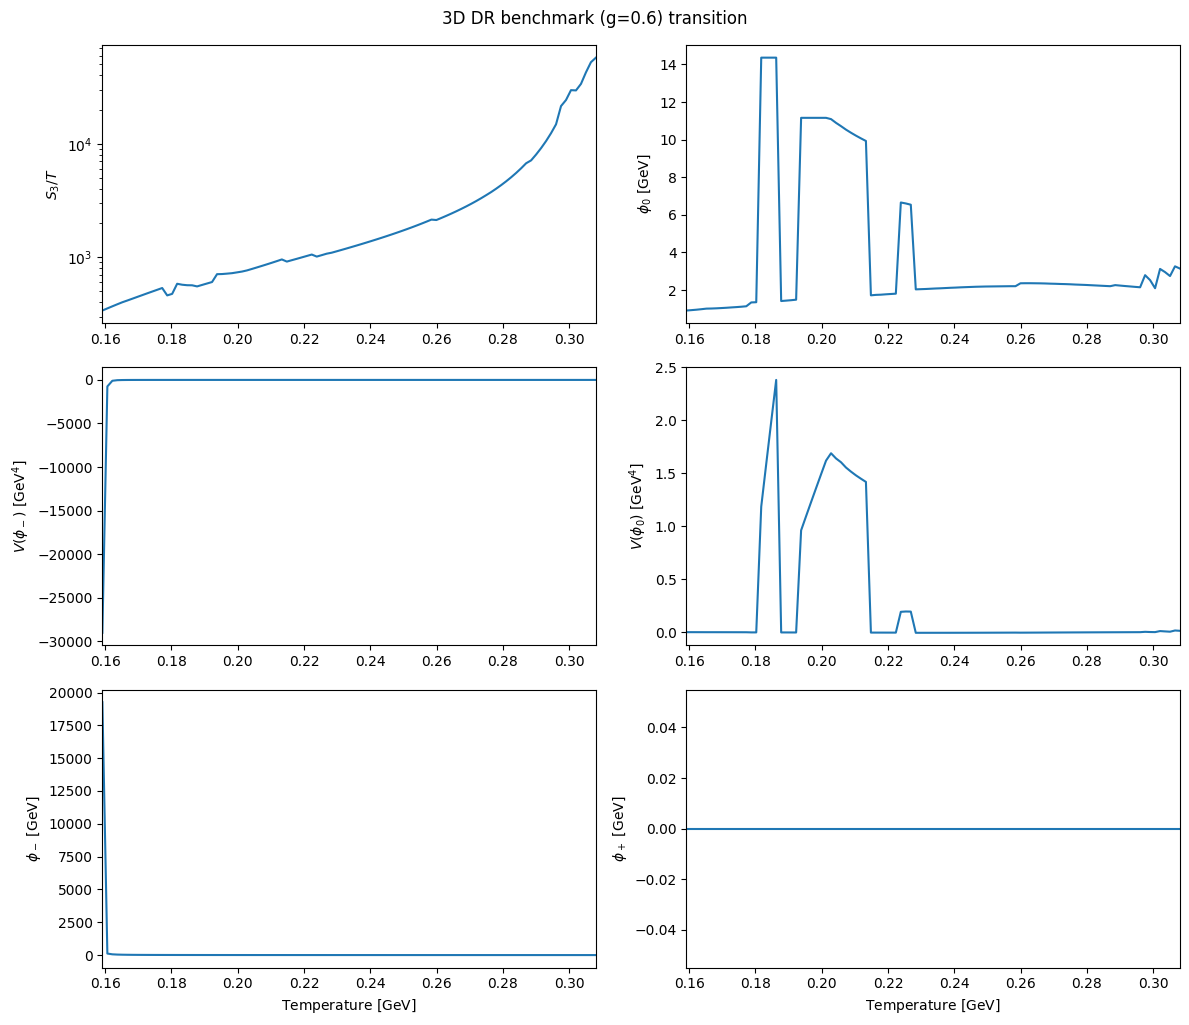

Minimum of the action at T = 1.59e-01 GeV


In [127]:
import matplotlib.pyplot as plt
import os

if len(temperatures) == 0:
    raise RuntimeError("No temperatures available for plotting.")

fig, axes = plt.subplots(3, 2, figsize=(12, 10))

S3_vals      = np.array([S3overT[T] for T in temperatures], dtype=float)
phi0_vals    = np.array([phi0_min[T] for T in temperatures], dtype=float)
Vmin_vals    = np.array([V_min_value[T] for T in temperatures], dtype=float)
Vexit_vals   = np.array([V_exit[T] for T in temperatures], dtype=float)
true_vals    = np.array([true_vev[T] for T in temperatures], dtype=float)
false_vals   = np.array([false_vev[T] for T in temperatures], dtype=float)

axes[0, 0].plot(temperatures, S3_vals)
axes[0, 0].set_ylabel(r'$S_3/T$')
axes[0, 0].set_yscale('log')

axes[0, 1].plot(temperatures, phi0_vals)
axes[0, 1].set_ylabel(f"$\\phi_0\\ \\mathrm{{[{units}]}}$")

axes[1, 0].plot(temperatures, Vmin_vals)
axes[1, 0].set_ylabel(f"$V(\\phi_-)\\ \\mathrm{{[{units}^4]}}$")

axes[1, 1].plot(temperatures, Vexit_vals)
axes[1, 1].set_ylabel(f"$V(\\phi_0)\\ \\mathrm{{[{units}^4]}}$")

axes[2, 0].plot(temperatures, true_vals)
axes[2, 0].set_xlabel(f"$\\mathrm{{Temperature\\ [{units}]}}$")
axes[2, 0].set_ylabel(f"$\\phi_-\\ \\mathrm{{[{units}]}}$")

axes[2, 1].plot(temperatures, false_vals)
axes[2, 1].set_xlabel(f"$\\mathrm{{Temperature\\ [{units}]}}$")
axes[2, 1].set_ylabel(f"$\\phi_+\\ \\mathrm{{[{units}]}}$")

for ax in axes.flatten():
    ax.set_xlim(np.min(temperatures), np.max(temperatures))

plt.tight_layout()
fig.suptitle(f'{description} transition', y=1.02)

# Save only if figure_dir exists
if 'figure_dir' in globals():
    os.makedirs(figure_dir, exist_ok=True)
    plt.savefig(os.path.join(figure_dir, f"action_{description}.pdf"), dpi=300, bbox_inches='tight')

plt.show()

T_at_min_action = temperatures[np.argmin(S3_vals)]
print(f"Minimum of the action at T = {T_at_min_action:.2e} {units}")